# 02 - MTOW Iteration

The Maximum Takeoff Weight (MTOW) cannot be determined directly because many mass components depend on MTOW itself. This creates a **circular dependency**:

```
MTOW  ──▶  Structural Mass  ──▶  Drag  ──▶  Power  ──▶  Energy  ──▶  Battery Mass  ──┐
  ▲                                                                                     │
  │                                                                                     │
  │                                                                                     │
  └──────────  MTOW_new = Empty Mass + Battery Mass + Payload  ◀────────────────────────┘
```

`evtolpy` resolves this by using **fixed-point iteration**:

1. Start with an initial MTOW guess (from the JSON file)
2. Compute energy requirements, battery mass, structural masses, and empty weight
3. Sum empty weight + battery + payload to get a new MTOW estimate
4. Repeat until $|MTOW_{new} - MTOW_{old}| < 0.001$ kg


In [22]:
import sys
sys.path.append('../../evtol')
from aircraft import Aircraft

aircraft = Aircraft('../../analysis/cfg-case-study/high-altitude-3000-ft/archer-midnight/60-miles/Archer-Midnight-3000-60.json')

## Running the Iteration

The `_iterate_mtow()` method returns the final converged MTOW and a history list showing each iteration.

In [23]:
final_mtow, history = aircraft._iterate_mtow()

print(f"Initial MTOW guess: {history[0]['mtow_guess_kg']:.2f} kg")
print(f"Converged MTOW:     {final_mtow:.2f} kg")
print(f"Iterations:         {len(history)}")

Initial MTOW guess: 3175.00 kg
Converged MTOW:     2448.44 kg
Iterations:         23


## Iteration History Table

In [24]:
print(f"{'Iter':>4s} {'Guess (kg)':>12s} {'New (kg)':>12s} {'Delta (kg)':>12s} {'Empty (kg)':>12s} {'Batt (kg)':>10s}")
print("-" * 65)
for row in history:
    print(f"{row['iteration']:>4d} {row['mtow_guess_kg']:>12.2f} {row['new_mtow_kg']:>12.2f} "
          f"{row['delta_kg']:>12.4f} {row['empty_mass_kg']:>12.2f} {row['battery_mass_kg']:>10.2f}")

Iter   Guess (kg)     New (kg)   Delta (kg)   Empty (kg)  Batt (kg)
-----------------------------------------------------------------
   0      3175.00      2868.93    -306.0728      1710.07     704.85
   1      2868.93      2685.64    -183.2867      1587.87     643.78
   2      2685.64      2580.34    -105.3000      1516.48     609.86
   3      2580.34      2521.18     -59.1613      1476.07     591.11
   4      2521.18      2488.37     -32.8129      1453.55     580.82
   5      2488.37      2470.30     -18.0673      1441.12     575.18
   6      2470.30      2460.39      -9.9080      1434.30     572.09
   7      2460.39      2454.97      -5.4214      1430.56     570.41
   8      2454.97      2452.01      -2.9628      1428.52     569.49
   9      2452.01      2450.39      -1.6181      1427.40     568.99
  10      2450.39      2449.51      -0.8834      1426.79     568.72
  11      2449.51      2449.02      -0.4822      1426.46     568.57
  12      2449.02      2448.76      -0.2632      1

## Visualize Convergence

The left plot shows MTOW converging from the initial guess to the final value. The right plot uses a log scale to show the exponential convergence rate, each iteration reduces the error.

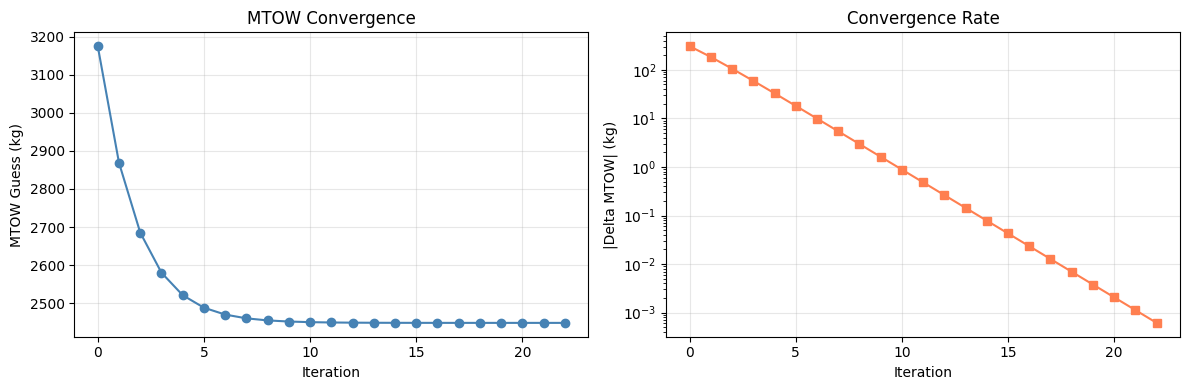

In [25]:
import matplotlib.pyplot as plt

iters = [row['iteration'] for row in history]
mtow_guesses = [row['mtow_guess_kg'] for row in history]
deltas = [abs(row['delta_kg']) for row in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(iters, mtow_guesses, 'o-', color='steelblue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('MTOW Guess (kg)')
ax1.set_title('MTOW Convergence')
ax1.grid(True, alpha=0.3)

ax2.semilogy(iters, deltas, 's-', color='coral')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('|Delta MTOW| (kg)')
ax2.set_title('Convergence Rate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Mass Component Evolution

The chart below shows how key mass components change between the first and last iteration.

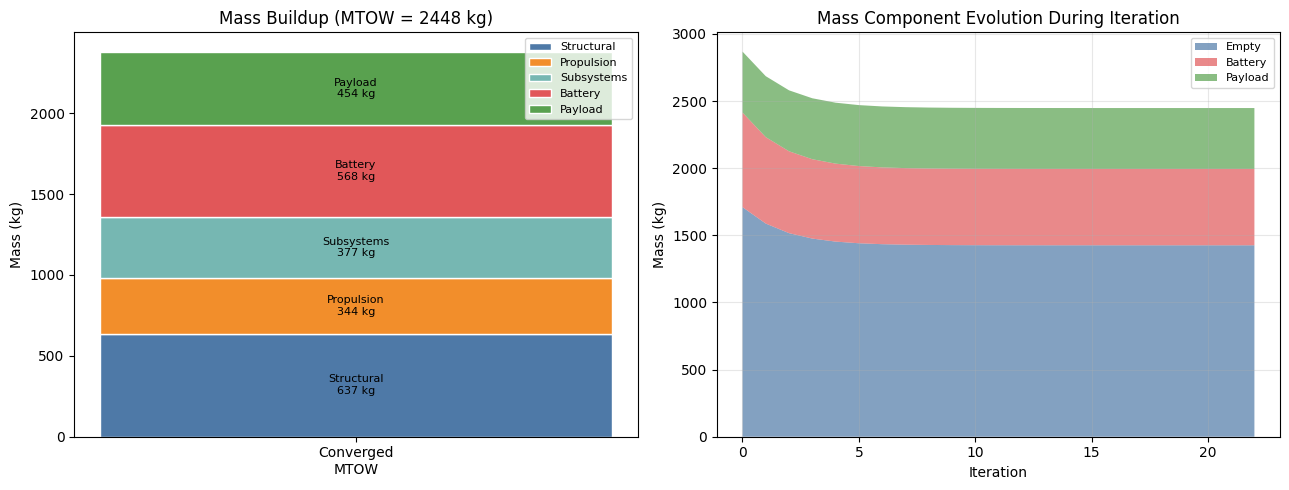

In [26]:
# Show the mass buildup for the converged aircraft as a stacked bar
categories = ['Structural', 'Propulsion', 'Subsystems', 'Battery', 'Payload']
cat_masses = [
    aircraft.wing_mass_kg + aircraft.horiz_tail_mass_kg + aircraft.vert_tail_mass_kg +
    aircraft.fuselage_mass_kg + aircraft.boom_mass_kg + aircraft.landing_gear_mass_kg,
    aircraft.epu_mass_kg + aircraft.lift_rotor_hub_mass_kg + aircraft.tilt_rotor_mass_kg,
    aircraft.actuator_mass_kg + aircraft.furnishings_mass_kg +
    aircraft.environmental_control_system_mass_kg + aircraft.avionics_mass_kg +
    aircraft.hivolt_power_dist_mass_kg + aircraft.lovolt_power_coms_mass_kg,
    aircraft.battery_mass_kg,
    aircraft.payload_kg
]
cat_colors = ['#4e79a7', '#f28e2b', '#76b7b2', '#e15759', '#59a14f']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Stacked bar showing mass buildup
bottom = 0
for name, mass, color in zip(categories, cat_masses, cat_colors):
    axes[0].bar('Converged\nMTOW', mass, bottom=bottom, color=color, edgecolor='white', label=name)
    if mass > 50:
        axes[0].text(0, bottom + mass/2, f'{name}\n{mass:.0f} kg', ha='center', va='center', fontsize=8)
    bottom += mass
axes[0].set_ylabel('Mass (kg)')
axes[0].set_title(f'Mass Buildup (MTOW = {final_mtow:.0f} kg)')
axes[0].legend(loc='upper right', fontsize=8)

# Convergence history with mass breakdown annotations
iters_all = [row['iteration'] for row in history]
empty_all = [row['empty_mass_kg'] for row in history]
batt_all = [row['battery_mass_kg'] for row in history]
payload_all = [aircraft.payload_kg] * len(history)

axes[1].stackplot(iters_all, empty_all, batt_all, payload_all,
                   labels=['Empty', 'Battery', 'Payload'],
                   colors=['#4e79a7', '#e15759', '#59a14f'], alpha=0.7)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Mass (kg)')
axes[1].set_title('Mass Component Evolution During Iteration')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

The MTOW iteration process couples:

- **Hover power** depends on MTOW through thrust requirement: $T = m \cdot g$, and induced velocity: $v_i = \sqrt{T/(2\rho A)}$
- **Cruise power** depends on MTOW through wing area (stall speed constraint) and drag
- **Energy requirements** sums power across all segments, driving battery mass
- **Battery mass** directly adds to MTOW
- **Structural mass** scales with MTOW through parametric equations

This coupling creates a **snowball effect** where any mass increase in one component cascades through the system. A 1 kg increase in payload requires more than 1 kg of additional MTOW because it requires more battery energy, which requires more battery mass, which requires more structural mass, and so on.

The stacked area plot shows how the empty mass and the battery mass both adjust during iteration until an equilibrium is found.

**Next:** Move on to [05 - Power and Energy Analysis]to examine per segment power and energy.